In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc

from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency

PROCESSED = Path("../data/processed")
REPORTS = Path("reports")
sns.set_style("whitegrid")

df = pd.read_parquet(PROCESSED / "application_train_clean.parquet")
print(f"Shape inicial: {df.shape}")

Shape inicial: (307511, 129)


In [2]:
housing_mode = [c for c in df.columns if c.endswith("_MODE")
                and c not in ("FONDKAPREMONT_MODE", "HOUSETYPE_MODE",
                              "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE")]
housing_medi = [c for c in df.columns if c.endswith("_MEDI")]
doc_flags    = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]
low_var_docs = [c for c in doc_flags if df[c].mean() < 0.001]
constants    = ["FLAG_MOBIL"]

to_drop = housing_mode + housing_medi + low_var_docs + constants
df_red = df.drop(columns=to_drop)

print(f"Columnas dropeadas: {len(to_drop)} ({len(housing_mode)+len(housing_medi)} housing, "
      f"{len(low_var_docs)} flags raros, {len(constants)} constantes)")
print(f"Shape: {df.shape} → {df_red.shape}")
print(f"Memoria: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB → "
      f"{df_red.memory_usage(deep=True).sum()/1024**2:.1f} MB")

del df; gc.collect()

Columnas dropeadas: 39 (29 housing, 9 flags raros, 1 constantes)
Shape: (307511, 129) → (307511, 90)
Memoria: 348.4 MB → 311.5 MB


0

In [3]:
numeric_cols = [c for c in df_red.select_dtypes(include=np.number).columns
                if c not in ("SK_ID_CURR", "TARGET")]
y = df_red["TARGET"]

auc_results = []
for col in numeric_cols:
    m = df_red[col].notna()
    if m.sum() == 0 or df_red.loc[m, col].nunique() < 2:
        continue
    auc_raw = roc_auc_score(df_red.loc[m, "TARGET"], df_red.loc[m, col])
    auc_results.append({
        "feature": col,
        "auc": round(max(auc_raw, 1 - auc_raw), 4),
        "direction": "↓ menos default" if auc_raw < 0.5 else "↑ más default",
        "pct_null": round(100 * df_red[col].isna().mean(), 2),
    })

auc_rank = pd.DataFrame(auc_results).sort_values("auc", ascending=False).reset_index(drop=True)
print(f"=== Top 25 numéricas por AUC univariada (de {len(auc_rank)} totales) ===")
print(auc_rank.head(25).to_string(index=False))
auc_rank.to_csv(REPORTS / "auc_rank_numeric.csv", index=False)

=== Top 25 numéricas por AUC univariada (de 72 totales) ===
                    feature    auc       direction  pct_null
               EXT_SOURCE_3 0.6794 ↓ menos default     19.83
               EXT_SOURCE_1 0.6657 ↓ menos default     56.38
               EXT_SOURCE_2 0.6561 ↓ menos default      0.21
                 DAYS_BIRTH 0.5830   ↑ más default      0.00
                  AGE_YEARS 0.5830 ↓ menos default      0.00
              DAYS_EMPLOYED 0.5824   ↑ más default     18.01
           EMPLOYMENT_YEARS 0.5824 ↓ menos default     18.01
                OWN_CAR_AGE 0.5589   ↑ más default     65.99
   YEARS_SINCE_PHONE_CHANGE 0.5569 ↓ menos default      0.00
     DAYS_LAST_PHONE_CHANGE 0.5569   ↑ más default      0.00
            DAYS_ID_PUBLISH 0.5557   ↑ más default      0.00
     YEARS_SINCE_ID_PUBLISH 0.5557 ↓ menos default      0.00
              FLOORSMAX_AVG 0.5504 ↓ menos default     49.76
REGION_RATING_CLIENT_W_CITY 0.5492   ↑ más default      0.00
       REGION_RATING_CLIE

In [4]:
def default_rate_by_cat(df, col, min_count=100):
    g = df.groupby(col, dropna=False).agg(
        n=("TARGET", "count"),
        default_rate_pct=("TARGET", lambda s: round(100 * s.mean(), 2))
    )
    g["pct_pop"] = (100 * g["n"] / len(df)).round(2)
    return g[g["n"] >= min_count].sort_values("default_rate_pct", ascending=False)

for col in ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "CODE_GENDER",
            "NAME_FAMILY_STATUS", "NAME_CONTRACT_TYPE"]:
    print(f"\n=== {col} ===")
    print(default_rate_by_cat(df_red, col))

# Para alta cardinalidad: top y bottom
for col in ["OCCUPATION_TYPE", "ORGANIZATION_TYPE"]:
    res = default_rate_by_cat(df_red, col, min_count=500)
    print(f"\n=== {col} (top 5 más riesgosas) ===")
    print(res.head(5))
    print(f"=== {col} (bottom 5 menos riesgosas) ===")
    print(res.tail(5))


=== NAME_INCOME_TYPE ===
                           n  default_rate_pct  pct_pop
NAME_INCOME_TYPE                                       
Working               158774              9.59    51.63
Commercial associate   71617              7.48    23.29
State servant          21703              5.75     7.06
Pensioner              55362              5.39    18.00

=== NAME_EDUCATION_TYPE ===
                                    n  default_rate_pct  pct_pop
NAME_EDUCATION_TYPE                                             
Lower secondary                  3816             10.93     1.24
Secondary / secondary special  218391              8.94    71.02
Incomplete higher               10277              8.48     3.34
Higher education                74863              5.36    24.34
Academic degree                   164              1.83     0.05

=== CODE_GENDER ===
                  n  default_rate_pct  pct_pop
CODE_GENDER                                   
M            105059             10.14  

In [5]:
cat_cols = df_red.select_dtypes(include="object").columns.tolist()

chi2_results = []
for col in cat_cols:
    sub = df_red[[col, "TARGET"]].dropna()
    if sub[col].nunique() < 2:
        continue
    ct = pd.crosstab(sub[col], sub["TARGET"])
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({
        "feature": col,
        "n_categories": sub[col].nunique(),
        "chi2": round(chi2, 1),
        "p_value": f"{p:.2e}",
        "cramers_v": round(v, 3),
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("cramers_v", ascending=False)
print("=== Asociación categórica ↔ TARGET (Cramér's V) ===")
print(chi2_df.to_string(index=False))
chi2_df.to_csv(REPORTS / "chi2_rank_categorical.csv", index=False)

=== Asociación categórica ↔ TARGET (Cramér's V) ===
                   feature  n_categories   chi2   p_value  cramers_v
           OCCUPATION_TYPE            18 1402.8 3.78e-288      0.082
          NAME_INCOME_TYPE             8 1253.5 1.93e-266      0.064
         ORGANIZATION_TYPE            57  899.7 1.84e-152      0.060
       NAME_EDUCATION_TYPE             5 1019.2 2.45e-219      0.058
               CODE_GENDER             2  920.0 4.39e-202      0.055
        NAME_FAMILY_STATUS             6  504.7 7.74e-107      0.041
         NAME_HOUSING_TYPE             6  420.6  1.10e-88      0.037
        NAME_CONTRACT_TYPE             2  293.2  1.02e-65      0.031
        WALLSMATERIAL_MODE             7  139.2  1.45e-27      0.030
              FLAG_OWN_CAR             2  146.7  9.33e-34      0.022
            HOUSETYPE_MODE             3   27.6  9.99e-07      0.013
        FONDKAPREMONT_MODE             4   16.8  7.73e-04      0.013
       EMERGENCYSTATE_MODE             2   23.7  1.

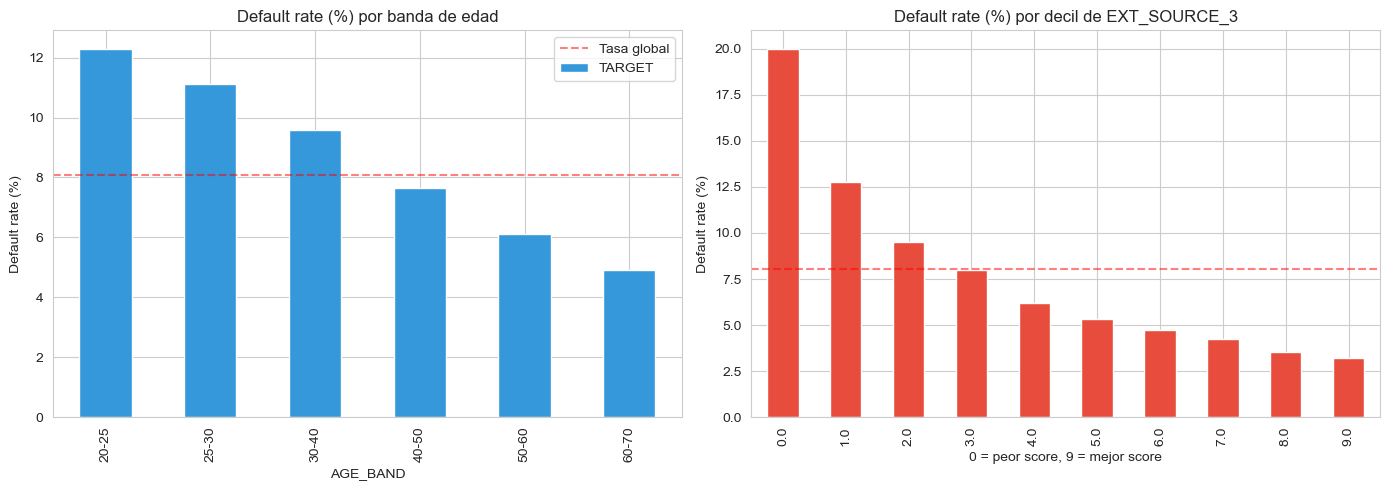

Default rate por banda de edad (%):
AGE_BAND
20-25    12.29
25-30    11.13
30-40     9.59
40-50     7.64
50-60     6.12
60-70     4.92
Name: TARGET, dtype: float64

Default rate por decil de EXT_SOURCE_3 (%):
EXT3_DEC
0.0    20.00
1.0    12.75
2.0     9.51
3.0     7.98
4.0     6.18
5.0     5.34
6.0     4.74
7.0     4.21
8.0     3.53
9.0     3.23
Name: TARGET, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate por banda de edad
df_red["AGE_BAND"] = pd.cut(df_red["AGE_YEARS"],
                            bins=[20, 25, 30, 40, 50, 60, 70],
                            labels=["20-25", "25-30", "30-40", "40-50", "50-60", "60-70"])
age_def = df_red.groupby("AGE_BAND", observed=True)["TARGET"].mean() * 100
age_def.plot(kind="bar", ax=axes[0], color="#3498db")
axes[0].set_title("Default rate (%) por banda de edad")
axes[0].axhline(8.07, color="red", linestyle="--", alpha=0.5, label="Tasa global")
axes[0].set_ylabel("Default rate (%)"); axes[0].legend()

# Default rate por decil de EXT_SOURCE_3
df_red["EXT3_DEC"] = pd.qcut(df_red["EXT_SOURCE_3"], 10, labels=False, duplicates="drop")
ext_def = df_red.groupby("EXT3_DEC")["TARGET"].mean() * 100
ext_def.plot(kind="bar", ax=axes[1], color="#e74c3c")
axes[1].set_title("Default rate (%) por decil de EXT_SOURCE_3")
axes[1].axhline(8.07, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("0 = peor score, 9 = mejor score")
axes[1].set_ylabel("Default rate (%)")

plt.tight_layout()
plt.savefig(REPORTS / "bivar_age_ext3.png", dpi=80, bbox_inches="tight")
plt.show()

print("Default rate por banda de edad (%):")
print(age_def.round(2))
print("\nDefault rate por decil de EXT_SOURCE_3 (%):")
print(ext_def.round(2))

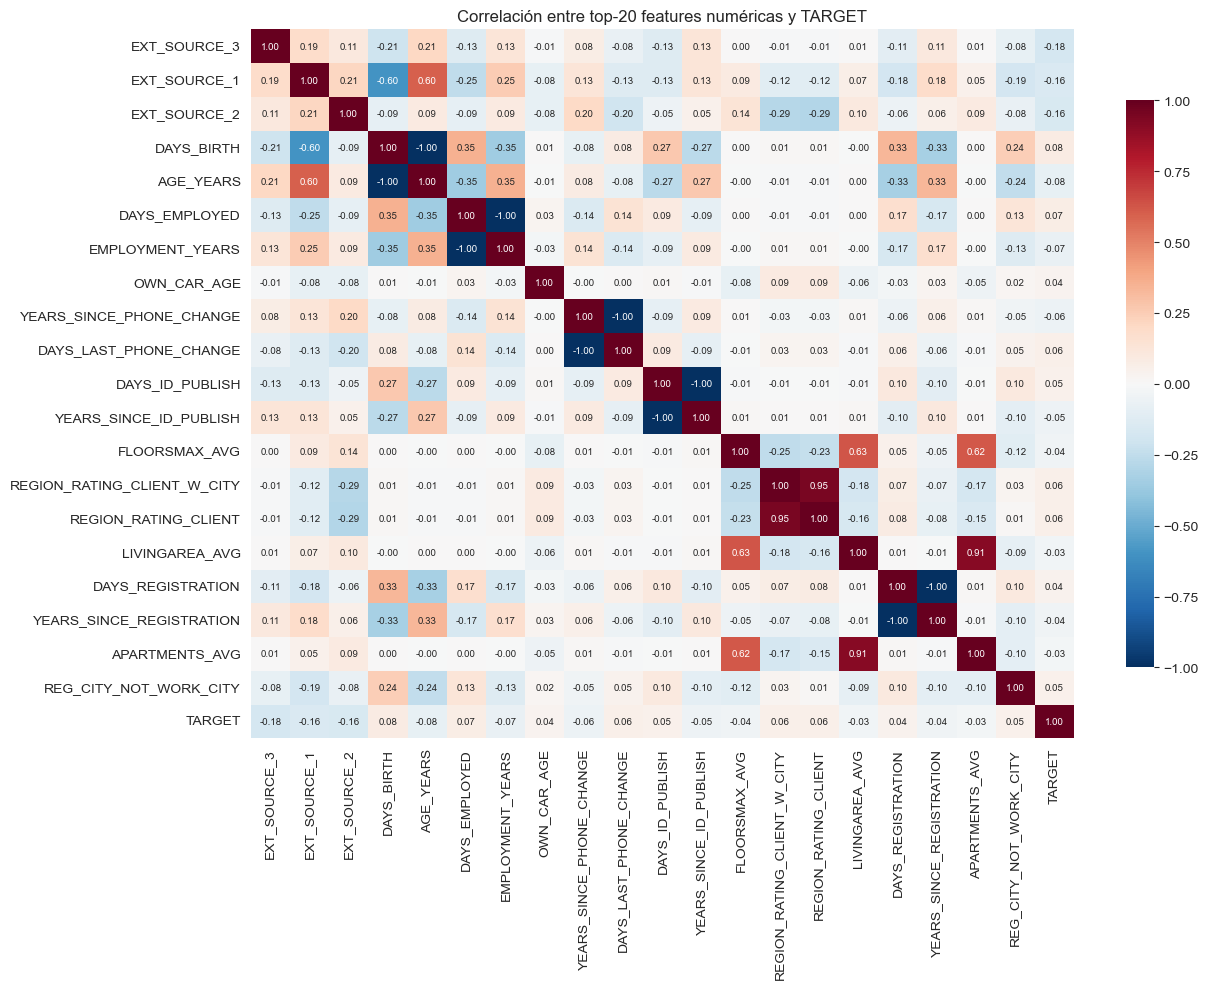

In [7]:
top_features = auc_rank.head(20)["feature"].tolist()
corr = df_red[top_features + ["TARGET"]].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlación entre top-20 features numéricas y TARGET")
plt.tight_layout()
plt.savefig(REPORTS / "bivar_corr_top20.png", dpi=80, bbox_inches="tight")
plt.show()

In [8]:
# Encoding rápido + imputación con centinela
df_mi = df_red.drop(columns=["AGE_BAND", "EXT3_DEC"], errors="ignore").copy()

# 1) Codificar categóricas (NaN → -1 como nivel discreto "faltante": correcto)
cat_encoded = df_mi.select_dtypes(include="object").columns.tolist()
for col in cat_encoded:
    df_mi[col] = df_mi[col].astype("category").cat.codes

X = df_mi.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_mi["TARGET"]

# 2) Numéricas: mediana, NO -1. El centinela crea un pico que rompe el k-NN
#    y mezcla "faltante" con "valor".
num_cols = [c for c in X.columns if c not in cat_encoded]
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# 3) Máscara discreta: categóricas + flags/ratings/conteos de baja cardinalidad.
discrete_mask = np.array([
    (col in cat_encoded) or (X[col].nunique() <= 20)
    for col in X.columns
])
print(f"Marcadas como discretas: {discrete_mask.sum()} / {len(discrete_mask)}")

mi = mutual_info_classif(X, y, discrete_features=discrete_mask,
                         random_state=42, n_jobs=-1)

mi_df = pd.DataFrame({"feature": X.columns, "mi": mi}).sort_values("mi", ascending=False)
print("\n=== Top 30 por Mutual Information ===")
print(mi_df.head(30).to_string(index=False))
mi_df.to_csv(REPORTS / "mi_rank.csv", index=False)

Marcadas como discretas: 50 / 88

=== Top 30 por Mutual Information ===
                    feature       mi
              FLOORSMIN_AVG 0.046756
                OWN_CAR_AGE 0.028914
            YEARS_BUILD_AVG 0.027849
       LIVINGAPARTMENTS_AVG 0.025931
              FLOORSMAX_AVG 0.022919
               EXT_SOURCE_1 0.020597
           BASEMENTAREA_AVG 0.020440
             APARTMENTS_AVG 0.018072
              ENTRANCES_AVG 0.017437
YEARS_BEGINEXPLUATATION_AVG 0.016842
               EXT_SOURCE_3 0.015852
               LANDAREA_AVG 0.015120
                AMT_ANNUITY 0.011950
               EXT_SOURCE_2 0.011843
             LIVINGAREA_AVG 0.010623
             COMMONAREA_AVG 0.010419
 AMT_REQ_CREDIT_BUREAU_YEAR 0.008788
                 AMT_CREDIT 0.007474
            AMT_GOODS_PRICE 0.006352
           EMPLOYMENT_YEARS 0.005831
              DAYS_EMPLOYED 0.005345
    HOUR_APPR_PROCESS_START 0.004897
 REGION_POPULATION_RELATIVE 0.004029
          NONLIVINGAREA_AVG 0.003542
   

In [9]:
combined = mi_df.merge(auc_rank[["feature", "auc", "direction"]], on="feature", how="left")
combined["mi_rank"]  = combined["mi"].rank(ascending=False, method="min").astype(int)
combined["auc_rank"] = combined["auc"].rank(ascending=False, method="min")
combined["score"]    = (combined["mi_rank"] + combined["auc_rank"].fillna(combined["auc_rank"].max())) / 2
combined = combined.sort_values("score").head(30)

print("=== Top 30 ranking combinado (MI + AUC) ===")
print(combined[["feature", "mi", "auc", "direction", "mi_rank", "auc_rank"]].to_string(index=False))
combined.to_csv(REPORTS / "ranking_combined_top30.csv", index=False)

=== Top 30 ranking combinado (MI + AUC) ===
                    feature       mi    auc       direction  mi_rank  auc_rank
               EXT_SOURCE_1 0.020597 0.6657 ↓ menos default        6       2.0
                OWN_CAR_AGE 0.028914 0.5589   ↑ más default        2       8.0
               EXT_SOURCE_3 0.015852 0.6794 ↓ menos default       11       1.0
               EXT_SOURCE_2 0.011843 0.6561 ↓ menos default       14       3.0
              FLOORSMAX_AVG 0.022919 0.5504 ↓ menos default        5      13.0
              FLOORSMIN_AVG 0.046756 0.5356 ↓ menos default        1      23.0
           EMPLOYMENT_YEARS 0.005831 0.5824 ↓ menos default       20       6.0
             APARTMENTS_AVG 0.018072 0.5397 ↓ menos default        8      19.0
              DAYS_EMPLOYED 0.005345 0.5824   ↑ más default       21       6.0
       LIVINGAPARTMENTS_AVG 0.025931 0.5355 ↓ menos default        4      24.0
                  AGE_YEARS 0.003501 0.5830 ↓ menos default       25       4.0
        

In [10]:
df_red = df_red.drop(columns=["AGE_BAND", "EXT3_DEC"])
df_red.to_parquet(PROCESSED / "application_train_reduced.parquet", index=False)

# Aplicar mismos drops al test
test = pd.read_parquet(PROCESSED / "application_test_clean.parquet")

test_doc_flags = [c for c in test.columns if c.startswith("FLAG_DOCUMENT_")]
test["DOCUMENTS_PROVIDED_COUNT"] = test[test_doc_flags].sum(axis=1).astype("int8")

test_drops = [c for c in to_drop if c in test.columns]
test_red = test.drop(columns=test_drops)
test_red.to_parquet(PROCESSED / "application_test_reduced.parquet", index=False)

print(f"Train reducido: {df_red.shape}")
print(f"Test reducido: {test_red.shape}")
print("Rango DOC_COUNT — train:",
      df_red['DOCUMENTS_PROVIDED_COUNT'].min(), "→", df_red['DOCUMENTS_PROVIDED_COUNT'].max(),
      "| test:", test_red['DOCUMENTS_PROVIDED_COUNT'].min(), "→", test_red['DOCUMENTS_PROVIDED_COUNT'].max())

Train reducido: (307511, 90)
Test reducido: (48744, 89)
Rango DOC_COUNT — train: 0 → 4 | test: 0 → 1
